In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    )

In [12]:
train_data =fetch_20newsgroups(
    subset ="train",
    remove=("headers","footers","quotes")
)

In [13]:
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [15]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [17]:
print("training documnts:",len(X_train_text))
print("testing documnts:",len(X_test_text))
print("number of classes :",len(class_names))

training documnts: 11314
testing documnts: 7532
number of classes : 20


In [18]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)
X_train =vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [19]:
print("Training feature matrix:",X_train.shape)
print("Testing feature matrix:",X_test.shape)


Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [21]:
mnb =MultinomialNB()
mnb.fit(
    X_train,
    y_train
)
y_pred_mnb = mnb.predict(X_test)

In [28]:
binary_vectorizer =CountVectorizer(
    stop_words="english" ,

    min_df = 2,
    binary= True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [29]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb = mnb.predict(X_test_binary)

In [32]:
results =pd.DataFrame({
    "Model":[
        "MUltinomial NB",
        "Bernoulli NB"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_mnb),
        accuracy_score(y_test,y_pred_bnb)
    ],
    "Precision":[
        precision_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        precision_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],
    "Recall":[
        recall_score(
            y_test,
            y_pred_mnb,
            average ="macro"
        ),
         recall_score(
            y_test,
            y_pred_bnb,
            average ="macro"
         )
    ],
    "F1-score":[
        f1_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
         f1_score(
            y_test,
            y_pred_bnb,
            average="macro"
         )
    ]
}
                     )
results


,Model,Accuracy,Precision,Recall,F1-score
0,MUltinomial NB,0.651089,0.634470,0.636933,0.617859
1,Bernoulli NB,0.647504,0.635318,0.633595,0.615149


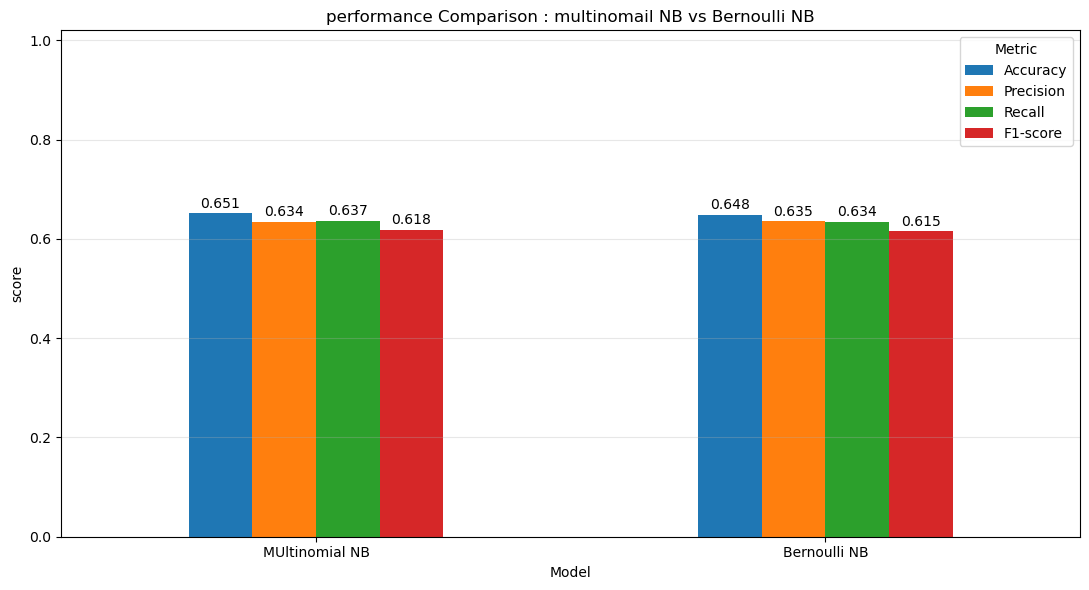

In [37]:
results_metrics =results[
    ["Model","Accuracy","Precision","Recall","F1-score"]
    ]
ax = results_metrics.set_index("Model").plot(
    kind="bar",
figsize=(11,6)
)
plt.title(
    "performance Comparison : multinomail NB vs Bernoulli NB")
plt.xlabel("Model")
plt.ylabel("score")
plt.ylim(0,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
    axis="y",
    alpha=0.3
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
    padding =2
    )
plt.tight_layout()
plt.show()